In [1]:
import numpy as np 
import sunpy
import sunpy.map 
import sunpy.coordinates
from sunpy.map import make_heliographic_header, make_fitswcs_header
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
        LogStretch, LinearStretch, CompositeStretch)
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy import ndimage

import sys
sys.path.append("/cluster/home/zhuyin/scripts/greensfield/")
import greensfield
from greensfield.util import make_boundary_magnetogram

import skimage.filters

In [2]:
sotsp_br_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_br_warp_to_hmi.fits")
sotsp_bt_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bt_warp_to_hmi.fits")
sotsp_bp_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bp_warp_to_hmi.fits")

sotsp_br_map = sotsp_br_map.submap([300, 100]*u.pix, top_right=[300+410-1, 100+400-1]*u.pix)
sotsp_bt_map = sotsp_bt_map.submap([300, 100]*u.pix, top_right=[300+410-1, 100+400-1]*u.pix)
sotsp_bp_map = sotsp_bp_map.submap([300, 100]*u.pix, top_right=[300+410-1, 100+400-1]*u.pix)


In [3]:
sotsp_map_bottom_left_hgs = sotsp_bp_map.bottom_left_coord.transform_to("heliographic_stonyhurst")
sotsp_map_center_hgs = sotsp_bp_map.center.transform_to("heliographic_stonyhurst")
sotsp_map_top_right_hgs = sotsp_bp_map.top_right_coord.transform_to("heliographic_stonyhurst")

In [4]:
scale_hgs = (sotsp_map_top_right_hgs.lon - sotsp_map_bottom_left_hgs.lon)/sotsp_bp_map.data.shape[1]/u.pix
# nx_hgs = np.round(((sotsp_map_top_right_hgs.lon - sotsp_map_bottom_left_hgs.lon)/scale_hgs).to_value(u.pix)).astype(int)
# ny_hgs = np.round(((sotsp_map_top_right_hgs.lat - sotsp_map_bottom_left_hgs.lat)/scale_hgs).to_value(u.pix)).astype(int)

nx_hgs = 384
ny_hgs = 384

In [5]:
hgs_header_0 = make_fitswcs_header(
    data=(ny_hgs, nx_hgs),
    coordinate=sotsp_map_center_hgs,
    scale=u.Quantity([scale_hgs, scale_hgs]),
    projection_code="CEA")
hgs_wcs_0 = WCS(hgs_header_0)

In [6]:
hgs_header_0

MetaDict([('wcsaxes': '2')
('crpix1': '192.5')
('crpix2': '192.5')
('cdelt1': '0.01814403078325923')
('cdelt2': '0.01814403078325923')
('cunit1': 'deg')
('cunit2': 'deg')
('ctype1': 'HGLN-CEA')
('ctype2': 'HGLT-CEA')
('crval1': '-24.968449613640303')
('crval2': '16.51627994892505')
('lonpole': '0.0')
('latpole': '90.0')
('mjdref': '0.0')
('date-obs': '2022-10-24T18:41:38.918')
('rsun_ref': '696000000.0')
('naxis': '2')
('naxis1': '384')
('naxis2': '384')
('pc1_1': '1.0')
('pc1_2': '-0.0')
('pc2_1': '0.0')
('pc2_2': '1.0')])

In [7]:
sotsp_br_map_hgs_0 = sotsp_br_map.reproject_to(hgs_wcs_0)

In [8]:
sotsp_br_map_hgs_0.save("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea.fits", overwrite=True)

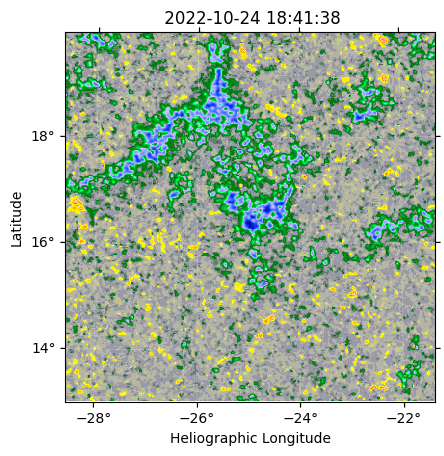

In [9]:
sotsp_br_map_hgs_0.plot(norm=ImageNormalize(vmin=-1500,vmax=1500),
                       cmap="hmimag")  

In [23]:
sotsp_br_map_hgs_0.scale.axis1.to_value(u.rad/u.pix)*695.7*384

84.59883244635765

In [10]:
sotsp_bp_map_hgs_0 = sotsp_bp_map.reproject_to(hgs_wcs_0)
sotsp_bt_map_hgs_0 = sotsp_bt_map.reproject_to(hgs_wcs_0)

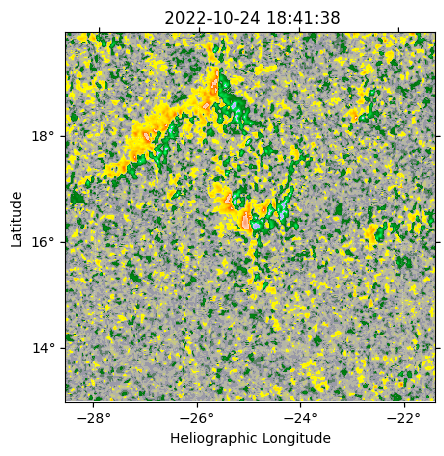

In [11]:
sotsp_bp_map_hgs_0.plot(norm=ImageNormalize(vmin=-1500,vmax=1500),
                       cmap="hmimag", interpolation="none")  

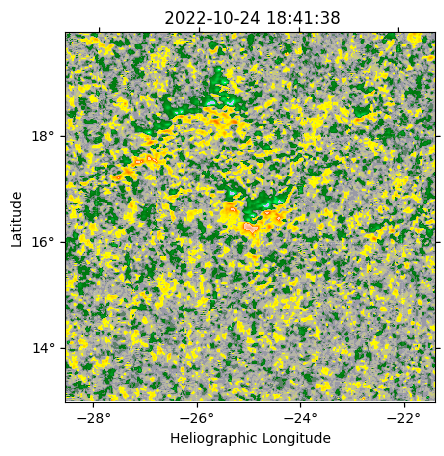

In [12]:
sotsp_bt_map_hgs_0.plot(norm=ImageNormalize(vmin=-1500,vmax=1500),
                       cmap="hmimag", interpolation="none")  

In [13]:
def xderiv2(arr,dx=None):
	if dx==None:
		dx=np.divide(1.0,arr.shape[0]-1)
	nx=arr.shape[0]
	ny=arr.shape[1]
	hidx=np.divide(0.5,dx)
	darr=hidx*(np.roll(arr,-1,axis=0)-np.roll(arr,+1,axis=0))
	darr[0,:]=hidx*(-3.*arr[0,:]+4.*arr[1,:]-arr[2,:])
	darr[nx-1,:]=hidx*(3.*arr[nx-1,:]-4.*arr[nx-2,:]+arr[nx-3,:])
	return darr

def yderiv2(arr,dy=None):
	if dy==None:
		dy=np.divide(1.0,arr.shape[1]-1)	
	nx=arr.shape[0]
	ny=arr.shape[1]
	hidy=np.divide(0.5,dy)
	darr=hidy*(np.roll(arr,-1,axis=1)-np.roll(arr,1,axis=1))
	darr[:,0]=hidy*(-3.*arr[:,0]+4.*arr[:,1]-arr[:,2])
	darr[:,ny-1]=hidy*(3.*arr[:,ny-1]-4.*arr[:,ny-2]+arr[:,ny-3])
	return darr

In [14]:
nx_rebin = nx_hgs
ny_rebin = ny_hgs
x = np.linspace(0, nx_rebin-1, nx_rebin)/nx_rebin
y = np.linspace(0, ny_rebin-1, ny_rebin)/ny_rebin

bx = sotsp_bp_map_hgs_0.data.T
# bx = np.nanmean(bx.reshape(nx_rebin, 4, ny_rebin, 4), axis=(1,3))
by = sotsp_bt_map_hgs_0.data.T
# by = np.nanmean(by.reshape(nx_rebin, 4, ny_rebin, 4), axis=(1,3))
bz = sotsp_br_map_hgs_0.data.T
# bz = np.nanmean(bz.reshape(nx_rebin, 4, ny_rebin, 4), axis=(1,3))

bx_smooth = skimage.filters.gaussian(bx, sigma=5)
by_smooth = skimage.filters.gaussian(by, sigma=5)
bz_smooth = skimage.filters.gaussian(bz, sigma=5)

dxby = np.gradient(by_smooth, x, axis=0)
dybx = np.gradient(bx_smooth, y, axis=1)

jz = dxby - dybx
alpha = jz/bz_smooth
alpha[bz < 100] = 0
alpha[np.abs(alpha) > 50] = 0
# alpha = alpha*0 + np.nanmedian(alpha)

sig = 20

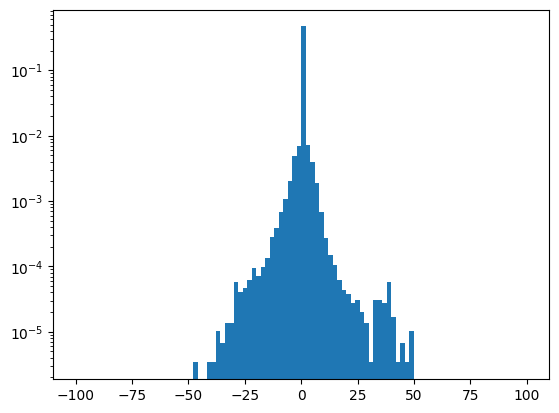

In [15]:
fig, ax = plt.subplots()
_ = ax.hist(alpha.flatten(), bins=100, density=True, range=(-100,100))
ax.set_yscale("log")
# ax.set_xlim(-np.sqrt(2)*np.pi, np.sqrt(2)*np.pi)

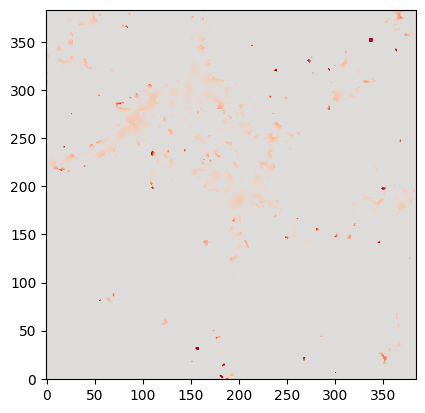

In [16]:
fig, ax = plt.subplots()
ax.imshow(np.abs(alpha.T), origin="lower", 
    norm=ImageNormalize(
    vmin=-30,
    vmax=30),
    cmap="coolwarm")

In [17]:
(bz/np.nanmax(np.abs(bz))).T.astype(np.float64).tofile("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1841_SOTSP/data/bz0.dat")
alpha.T.astype(np.float64).tofile("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1841_SOTSP/data/alpha0.dat")

In [34]:
np.nansum(alpha)/np.nansum(alpha!=0)/(sotsp_br_map_hgs_0.scale.axis1.to_value(u.rad/u.pix)*695.7*384)

0.005781897738767225

In [18]:
print(np.nanmax(np.abs(bz)))

1378.5997874387754


In [19]:
np.save("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea.npy", bz)
np.save("../../data/pid_1_123_aux/SOTSP/sotsp_alpha_hgs_cea.npy", alpha)

In [15]:
def laplace(field):
    """
    Compute the Laplacian of a 2D field using the 5-point stencil method.
    """
    return (-4 * field + 
            np.roll(field, 1, axis=0) + 
            np.roll(field, -1, axis=0) + 
            np.roll(field, 1, axis=1) + 
            np.roll(field, -1, axis=1))

def prepro(mu3, mu4, bx, by, bz, nx, ny, nz, noprint=False):
    """
    Preprocessing of vector magnetograms for a nonlinear force-free magnetic field reconstruction.
    
    The method is described in:
    T. Wiegelmann, B. Inhester, T.Sakurai:
    Preprocessing of vector magnetograph data
    for a nonlinear force-free magnetic field reconstruction.
    (Solar Physics, Vol. 233, 215-232, 2006.)
    
    Parameters:
    -----------
    mu3 : float
        Weight for data fidelity term (observation constraint)
    mu4 : float
        Weight for smoothing term
    bx, by, bz : numpy.ndarray
        Vector magnetogram components
    nx, ny, nz : int
        Grid dimensions
    noprint : bool, optional
        Flag to suppress printing
        
    Returns:
    --------
    subL : list
        List containing the final values of the subfunctionals [L1+L2, L3, L4]
    """
    # Check input data
    if bx is None or by is None or bz is None:
        print('Input fields Bx, By, Bz must exist and have same size.')
        return None
    
    # Create coordinate grid
    x1 = np.linspace(0, 1, nx)
    y1 = np.linspace(0, 1, ny)
    
    # Grid spacing
    dx = 1.0/(nx-1)
    dy = 1.0/(ny-1)
    dxdy = dx * dy
    
    # Create 2D coordinate arrays
    x = np.zeros((nx, ny))
    y = np.zeros((nx, ny))
    for iy in range(ny):
        x[:, iy] = x1
    for ix in range(nx):
        y[ix, :] = y1
    
    # Normalize the magnetogram
    bave2d = np.mean(np.sqrt(bx**2 + by**2 + bz**2))
    bx = bx / bave2d
    by = by / bave2d
    bz = bz / bave2d
    
    # Store original magnetogram
    bxo = bx.copy()
    byo = by.copy()
    bzo = bz.copy()
    bx1 = bx.copy()
    by1 = by.copy()
    bz1 = bz.copy()
    
    # Define weights for optimization terms
    mu1 = 1.0  # Force
    mu2 = mu1  # Torque
    
    fac1 = 10.0
    mu1 = mu1 / fac1
    mu2 = mu2 / fac1
    mu3 = mu3 / fac1
    mu4 = mu4 / fac1
    
    if not noprint:
        print(mu1, mu2, mu3, mu4)
    
    emag = np.sum(bx**2 + by**2 + bz**2)
    emag2 = emag**2
    
    # Calculate r = sqrt(x^2 + y^2) for torque calculation
    r = np.sqrt(x**2 + y**2)
    ihelp = np.sum(r * (bx**2 + by**2 + bz**2))
    ihelp2 = ihelp**2
    
    # Iteration counter
    it = -1
    L = 10
    dL = 1.0
    emag = np.sum(bx**2 + by**2 + bz**2)
    
    # Main iteration loop
    while it < 2000 and dL > 1.0e-4:
        it += 1
        
        # Force terms
        term1a = np.sum(bx * bz) / emag
        term1b = np.sum(by * bz) / emag
        term1c = (np.sum(bz**2) - np.sum(bx**2 + by**2)) / emag
        
        # Torque terms
        term2a = (np.sum(x * bz**2) - np.sum(x * (bx**2 + by**2))) / ihelp
        term2b = (np.sum(y * bz**2) - np.sum(y * (bx**2 + by**2))) / ihelp
        term2c = (np.sum(y * bx * bz) - np.sum(x * by * bz)) / ihelp
        
        # Data fidelity terms
        term3a = (bx1 - bxo)**2 / emag
        term3b = (by1 - byo)**2 / emag
        term3c = (bz1 - bzo)**2 / emag
        
        # Smoothing terms
        term4a = 2.0 * (-4.0 * laplace(bx) + 
                        laplace(np.roll(bx, 1, axis=0)) + 
                        laplace(np.roll(bx, -1, axis=0)) + 
                        laplace(np.roll(bx, 1, axis=1)) + 
                        laplace(np.roll(bx, -1, axis=1)))
                       
        term4b = 2.0 * (-4.0 * laplace(by) + 
                        laplace(np.roll(by, 1, axis=0)) + 
                        laplace(np.roll(by, -1, axis=0)) + 
                        laplace(np.roll(by, 1, axis=1)) + 
                        laplace(np.roll(by, -1, axis=1)))
                       
        term4c = 2.0 * (-4.0 * laplace(bz) + 
                        laplace(np.roll(bz, 1, axis=0)) + 
                        laplace(np.roll(bz, -1, axis=0)) + 
                        laplace(np.roll(bz, 1, axis=1)) + 
                        laplace(np.roll(bz, -1, axis=1)))
        
        # Calculate functional values
        L1 = term1a**2 + term1b**2 + term1c**2
        L2 = term2a**2 + term2b**2 + term2c**2
        L12 = L1 + L2
        L3 = np.sum(term3a + term3b + term3c) / emag
        L4 = dxdy * np.sum(laplace(bx)**2 + laplace(by)**2 + laplace(bz)**2) / emag
        L = L1 + L2 + L3 + L4
        
        # Calculate change in functional
        if it > 0:
            dL = (abs(L12 - oldL12) / L12 + 
                 abs(L3 - oldL3) / L3 + 
                 abs(L4 - oldL4) / L4)
        
        if (it % 50) == 0 and not noprint:
            print(dL)
            print(it, L12, L3, L4)
        
        oldL12 = L12
        oldL3 = L3
        oldL4 = L4
        
        # Update magnetic field components
        bx1 = (bx + mu1 * (-2. * term1a * bz + 4. * term1c * bx) - 
              mu3 * 2. * (bx - bxo) - mu4 * term4a + 
              mu2 * (4. * term2a * x * bx + 4. * term2b * y * bx - 2. * term2c * y * bz))
              
        by1 = (by + mu1 * (-2. * term1b * bz + 4. * term1c * by) - 
              mu3 * 2. * (by - byo) - mu4 * term4b + 
              mu2 * (4. * term2a * x * by + 4. * term2b * y * by + 2. * term2c * x * bz))
              
        bz1 = bz - mu3 * 2. * (bz - bzo) - mu4 * term4c
        
        bx = bx1
        by = by1
        bz = bz1
    
    # Return to original scaling
    bx = bx * bave2d
    by = by * bave2d
    bz = bz * bave2d
    
    if not noprint:
        print('Correct magnetogram finished')
    
    subL = [L1 + L2, L3, L4]
    return bx, by, bz, subL

In [16]:
bx_prepro, by_prepro, bz_prepro, _ = prepro(1e-2, 1e-2, bx, by, bz, nx_rebin, ny_rebin, nx_rebin, noprint=True)

In [17]:
dxby_prepro = np.gradient(by_prepro, x, axis=0)
dybx_prepro = np.gradient(bx_prepro, y, axis=1)

jz_prepro = dxby_prepro - dybx_prepro
alpha_prepro = jz_prepro/bz_prepro
alpha_prepro[np.isnan(alpha_prepro)] = 0

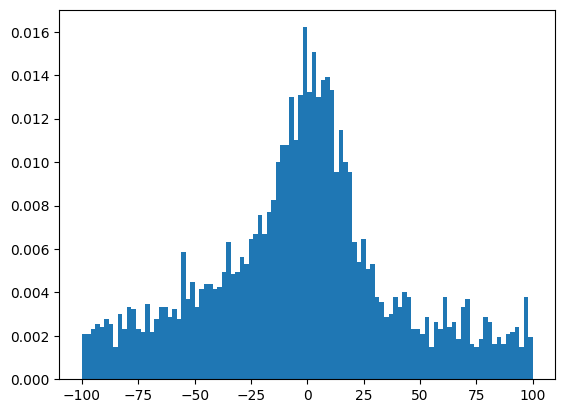

In [18]:
fig, ax = plt.subplots()
_ = ax.hist(alpha_prepro.flatten(), bins=100, density=True, range=(-100, 100))

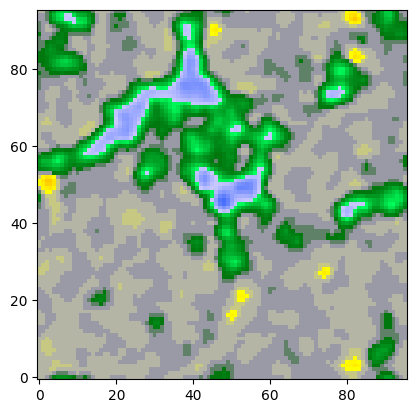

In [19]:
plt.imshow(bz_prepro.T, origin="lower",
           norm=ImageNormalize(vmin=-1500, vmax=1500),
           cmap="hmimag", interpolation="none")

In [74]:
bz_prepro.T.astype(np.float64).tofile("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1841_SOTSP/data/bz0_prepro.dat")
alpha_prepro.T.astype(np.float64).tofile("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1841_SOTSP/data/alpha0_prepro.dat")

In [40]:
with fits.open("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1912_SHARP/magnetograms/hmi.sharp_cea_720s.8718.20221024_191200_TAI.Br.fits") as hdul:
    hmi_br_map = hdul[1].data.copy()
with fits.open("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1912_SHARP/magnetograms/hmi.sharp_cea_720s.8718.20221024_191200_TAI.Bt.fits") as hdul:
    hmi_bt_map = hdul[1].data.copy()
with fits.open("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1912_SHARP/magnetograms/hmi.sharp_cea_720s.8718.20221024_191200_TAI.Bp.fits") as hdul:
    hmi_bp_map = hdul[1].data.copy()

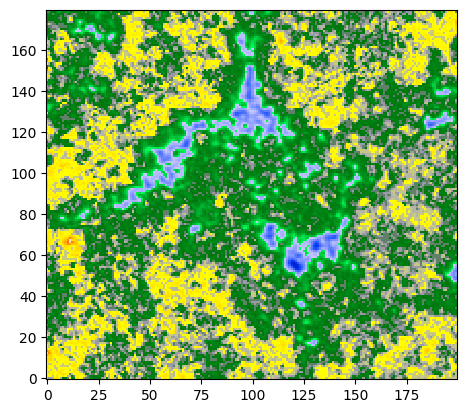

In [41]:
fig, ax = plt.subplots()
ax.imshow(hmi_br_map[20:200, 300:500], origin="lower",
          norm=ImageNormalize(vmin=-1500, vmax=1500),
          cmap="hmimag", interpolation="none")

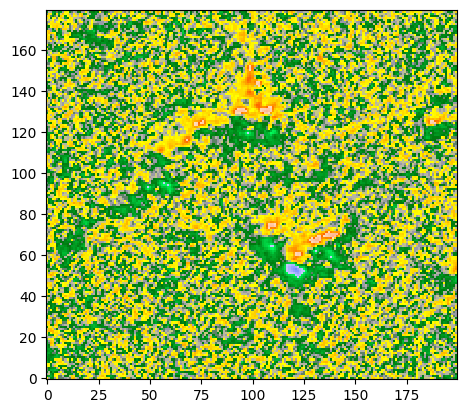

In [42]:
fig, ax = plt.subplots()
ax.imshow(hmi_bt_map[20:200, 300:500], origin="lower",
          norm=ImageNormalize(vmin=-1500, vmax=1500),
          cmap="hmimag", interpolation="none")

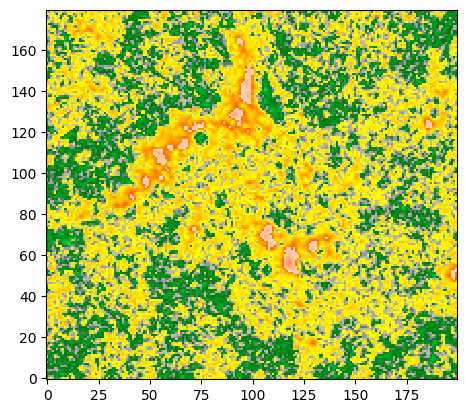

In [43]:
fig, ax = plt.subplots()
ax.imshow(hmi_bp_map[20:200, 300:500], origin="lower",
          norm=ImageNormalize(vmin=-1500, vmax=1500),
          cmap="hmimag", interpolation="none")

In [46]:
nx_sharp = hmi_br_map.shape[1]
ny_sharp = hmi_br_map.shape[0]

x_sharp = np.linspace(0, nx_sharp-1, nx_sharp)/nx_sharp
y_sharp = np.linspace(0, ny_sharp-1, ny_sharp)/ny_sharp

bx_sharp = hmi_bp_map.T
by_sharp = hmi_bt_map.T
bz_sharp = hmi_br_map.T

dxby_sharp = np.gradient(by_sharp, x_sharp, axis=0)
dybx_sharp = np.gradient(bx_sharp, y_sharp, axis=1)

jz_sharp = dxby_sharp - dybx_sharp
alpha_sharp = jz_sharp/bz_sharp
alpha_sharp[np.isnan(alpha_sharp)] = 0

/scratch/tmp.32116070.zhuyin/ipykernel_1253536/578387652.py:15: RuntimeWarning: divide by zero encountered in divide
  alpha_sharp = jz_sharp/bz_sharp


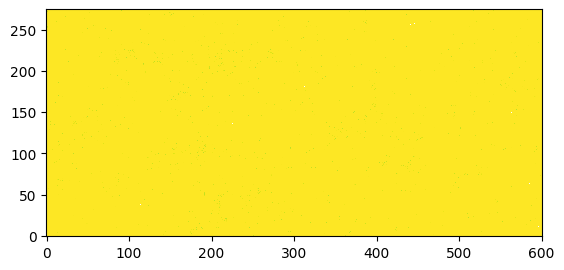

In [48]:
fig, ax = plt.subplots()
ax.imshow(np.abs(alpha_sharp.T), origin="lower", 
    norm=ImageNormalize(
    vmin=-np.sqrt(2)*np.pi,
    vmax=np.sqrt(2)*np.pi,
    stretch=LogStretch()),
    interpolation="none")

In [ ]:
sotsp_br_map_hpc = make_boundary_magnetogram(
                    sotsp_br_map,
                    sotsp_map_center_hgs,
                    [(0,0)*u.pix, sotsp_br_map.data.shape[::-1]*u.pix],
                    resample_factor=1)

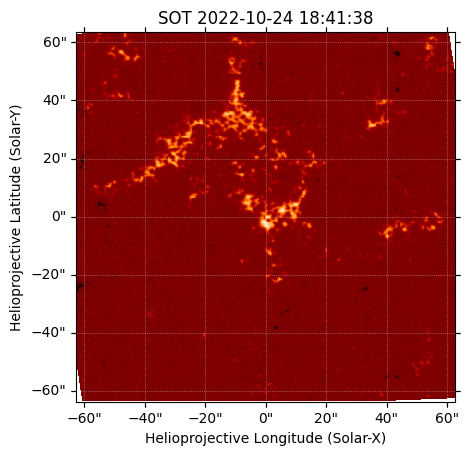

In [ ]:
sotsp_br_map_hpc.plot()